# Plant Disease Detection 

## EDA 

In [1]:
import tensorflow as tf
print(tf.__version__)


2.15.0


In [2]:
# import Libraries

import os
import matplotlib.pyplot as plt
from PIL import Image
import random
import tensorflow as tf
from tensorflow.keras import models, layers
import matplotlib.pyplot as plt
from IPython.display import HTML


In [3]:
# Load dataset 
 
data = "apple"

# Cheking how big dataset is

total_images = 0

for folder in os.listdir(data):
    folder_path = os.path.join(data, folder)

    if os.path.isdir(folder_path):
        total_images += len(os.listdir(folder_path))

print("Total number of images:", total_images)

# List Clases 

classes = os.listdir(data)
print("Total number of classes:", len(classes))
print("class names:", classes[:10])



Total number of images: 3171
Total number of classes: 4
class names: ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy']


In [4]:
# Count Images in Each Class

image_count = {}

for cls in classes:
    class_path = os.path.join(data, cls)
    image_count[cls] = len(os.listdir(class_path))

print("Total Images per Class:",image_count)

# Cheking which class has lowest images which has highest images

class_counts = {
    cls: len(os.listdir(os.path.join(data, cls)))
    for cls in classes
}

print('Min images in a class:', min(class_counts.values()))
print('Max images in a class:', max(class_counts.values()))


Total Images per Class: {'Apple___Apple_scab': 630, 'Apple___Black_rot': 621, 'Apple___Cedar_apple_rust': 275, 'Apple___healthy': 1645}
Min images in a class: 275
Max images in a class: 1645


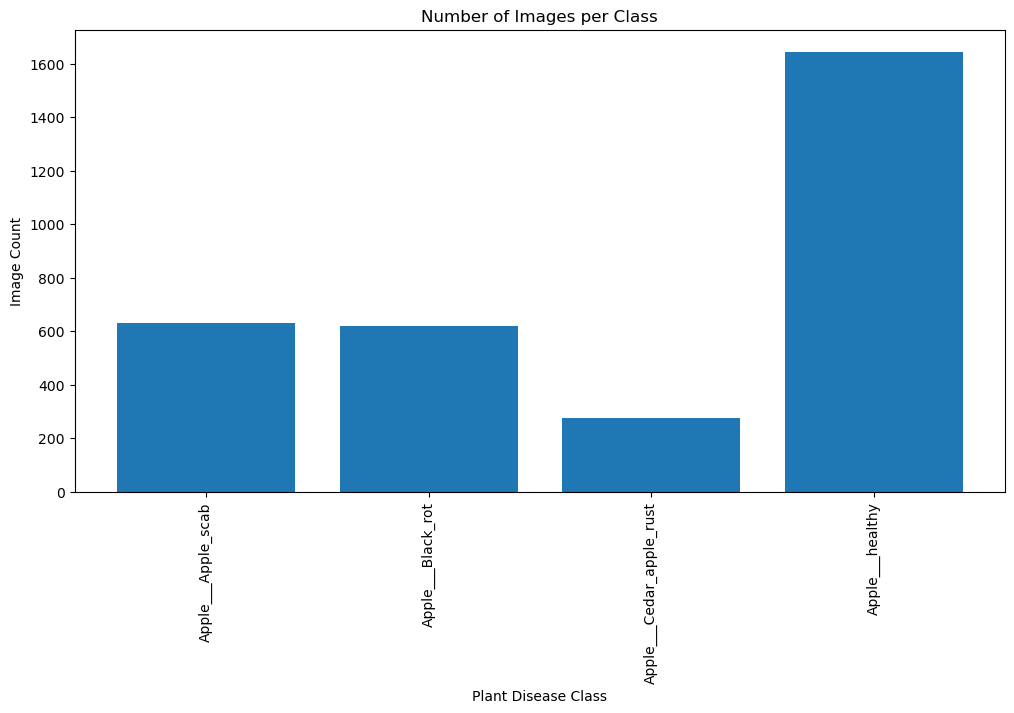

In [5]:
#Plot Class Distribution (Most Important EDA)

plt.figure(figsize=(12,6))
plt.bar(image_count.keys(), image_count.values())
plt.xticks(rotation=90)
plt.title("Number of Images per Class")
plt.xlabel("Plant Disease Class")
plt.ylabel("Image Count")
plt.show()

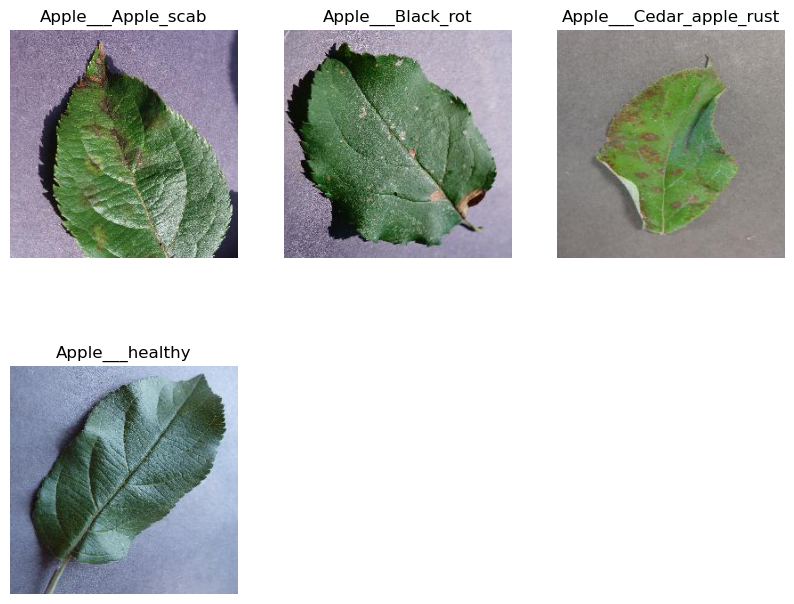

In [6]:
# Show Sample Images (Visual Inspection)

plt.figure(figsize=(10,8))

for i, cls in enumerate(classes[:6]):
    class_path = os.path.join(data, cls)
    img_name = random.choice(os.listdir(class_path))
    img_path = os.path.join(class_path, img_name)

    img = Image.open(img_path)

    plt.subplot(2, 3, i+1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis("off")

plt.show()

In [7]:
# Check Image Sizes

widths = []
heights = []

for cls in classes[:5]:  # only first 5 classes to keep it simple
    class_path = os.path.join(data, cls)
    for img_name in os.listdir(class_path):
        img = Image.open(os.path.join(class_path, img_name))
        w, h = img.size
        widths.append(w)
        heights.append(h)

print(widths)
print(heights)

[256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256,

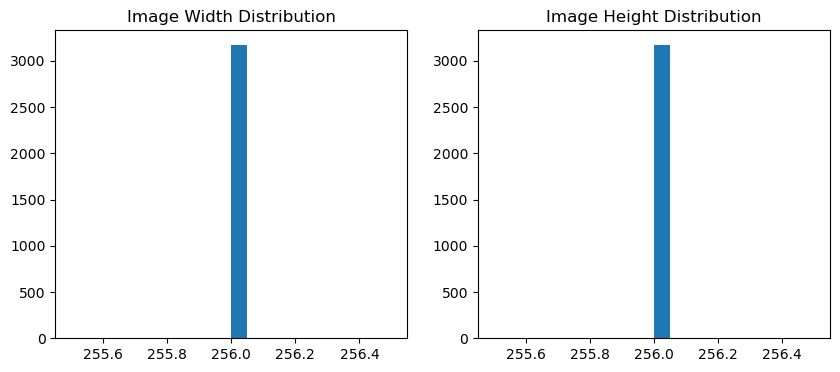

In [8]:
# Plot Image Size Distribution

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.hist(widths, bins=20)
plt.title("Image Width Distribution")

plt.subplot(1,2,2)
plt.hist(heights, bins=20)
plt.title("Image Height Distribution")

plt.show()

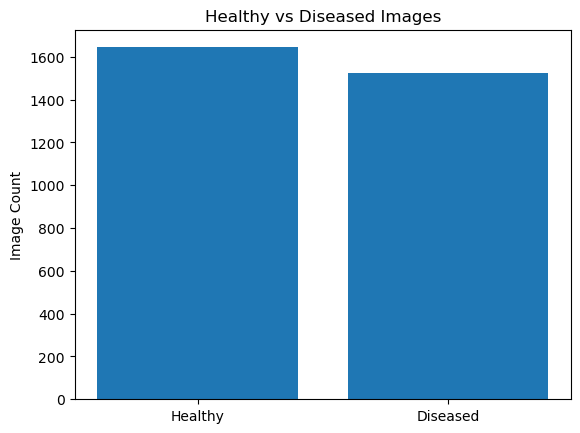

In [9]:
# Healthy vs Diseased Images Count

healthy = 0
diseased = 0

for cls in classes:
    if "healthy" in cls.lower():
        healthy += len(os.listdir(os.path.join(data, cls)))
    else:
        diseased += len(os.listdir(os.path.join(data, cls)))

plt.bar(["Healthy", "Diseased"], [healthy, diseased])
plt.title("Healthy vs Diseased Images")
plt.ylabel("Image Count")
plt.show()


## Model Building 

In [10]:
# Setting Hyperparameters 

BATCH_SIZE = 32
IMAGE_SIZE = 256
CHANNELS=3
EPOCHS=30



In [11]:
dataset = tf.keras.preprocessing.image_dataset_from_directory(
    "apple",
    seed=123,
    shuffle=True,
    image_size=(IMAGE_SIZE,IMAGE_SIZE),
    batch_size=BATCH_SIZE
)

Found 3171 files belonging to 4 classes.


In [12]:
len(dataset)

100

In [13]:
# Making the partion of data into train, validation and test.

def get_dataset_partitions_tf(ds, train_split=0.8, val_split=0.1, test_split=0.1, shuffle=True, shuffle_size=100):
    assert (train_split + test_split + val_split) == 1
    
    ds_size = len(ds)
    
    if shuffle:
        ds = ds.shuffle(shuffle_size, seed=12)
    
    train_size = int(train_split * ds_size)
    val_size = int(val_split * ds_size)
    
    train_ds = ds.take(train_size)    
    val_ds = ds.skip(train_size).take(val_size)
    test_ds = ds.skip(train_size).skip(val_size)
    
    return train_ds, val_ds, test_ds

train_ds, val_ds, test_ds = get_dataset_partitions_tf(dataset)

In [14]:
#  printing the length of data in particular part 

print("Length of train data:",len(train_ds))
print("Length of Validation data:",len(val_ds))
print("Length of test data:",len(test_ds))

Length of train data: 80
Length of Validation data: 10
Length of test data: 10


In [15]:
# Here we are using cache and prefetch to reduce the time in training

# cache is used to store the images in CPU.So, they do not have to look it every time in each epoch and they they can directly run it.
# prefetch is loading the next batch in CPU while running the previous one in GPU.

train_ds = train_ds.cache().shuffle(100).prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds.cache().shuffle(100).prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds = test_ds.cache().shuffle(100).prefetch(buffer_size=tf.data.AUTOTUNE)

In [16]:
# Normalization of data
resize_and_rescale = tf.keras.Sequential([
    layers.Resizing(IMAGE_SIZE, IMAGE_SIZE),
    layers.Rescaling(1./255),
])

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
])

In [17]:
train_ds = train_ds.map(
    lambda x, y: (data_augmentation(x, training=True), y)
).prefetch(buffer_size=tf.data.AUTOTUNE)

In [18]:
input_shape = (BATCH_SIZE, IMAGE_SIZE, IMAGE_SIZE, CHANNELS)
n_classes = 4

model = models.Sequential([
    resize_and_rescale,data_augmentation,
    layers.Conv2D(64, kernel_size = (3,3), activation='relu', input_shape=input_shape),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64,  kernel_size = (3,3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64,  kernel_size = (3,3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(n_classes, activation='softmax'),
])

model.build(input_shape=input_shape)

In [19]:
model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 sequential (Sequential)     (32, 256, 256, 3)         0         
                                                                 
 sequential_1 (Sequential)   (None, 256, 256, 3)       0         
                                                                 
 conv2d (Conv2D)             (32, 254, 254, 64)        1792      
                                                                 
 max_pooling2d (MaxPooling2  (32, 127, 127, 64)        0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (32, 125, 125, 64)        36928     
                                                                 
 max_pooling2d_1 (MaxPoolin  (32, 62, 62, 64)          0         
 g2D)                                                 

In [20]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [21]:
history = model.fit(
    train_ds,
    epochs=EPOCHS,
    validation_data=val_ds
)

Epoch 1/30


80/80 [==============================] - 315s 4s/step - loss: 1.1795 - accuracy: 0.5168 - val_loss: 1.1828 - val_accuracy: 0.5636
Epoch 2/30
80/80 [==============================] - 331s 4s/step - loss: 0.8537 - accuracy: 0.6100 - val_loss: 0.9719 - val_accuracy: 0.6735
Epoch 3/30
80/80 [==============================] - 310s 4s/step - loss: 0.7498 - accuracy: 0.6685 - val_loss: 1.1829 - val_accuracy: 0.6529
Epoch 4/30
80/80 [==============================] - 418s 5s/step - loss: 0.6855 - accuracy: 0.7096 - val_loss: 0.8109 - val_accuracy: 0.7113
Epoch 5/30
80/80 [==============================] - 329s 4s/step - loss: 0.6814 - accuracy: 0.7262 - val_loss: 1.1243 - val_accuracy: 0.6735
Epoch 6/30
80/80 [==============================] - 246s 3s/step - loss: 0.5510 - accuracy: 0.7831 - val_loss: 0.7641 - val_accuracy: 0.7491
Epoch 7/30
80/80 [==============================] - 245s 3s/step - loss: 0.4486 - accuracy: 0.8234 - val_loss: 1.0524 - val_accuracy: 0.6632
Epoch 8/30


In [22]:
scores = model.evaluate(test_ds)

10/10 [==============================] - 18s 591ms/step - loss: 0.3816 - accuracy: 0.9250


In [23]:
scores

[0.3815864622592926, 0.925000011920929]

In [24]:
history

In [25]:
history.params

{'verbose': 1, 'epochs': 30, 'steps': 80}

In [26]:
history.history.keys()

dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])

In [27]:
type(history.history['loss'])

list

In [28]:
len(history.history['loss'])

30

In [29]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

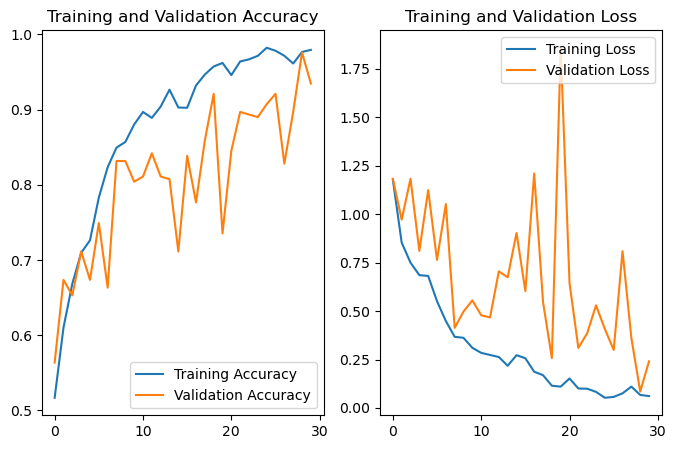

In [30]:
plt.figure(figsize=(8, 5))
plt.subplot(1, 2, 1)
plt.plot(range(EPOCHS), acc, label='Training Accuracy')
plt.plot(range(EPOCHS), val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(range(EPOCHS), loss, label='Training Loss')
plt.plot(range(EPOCHS), val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

first image to predict
actual label: Apple___healthy
1/1 [==============================] - 3s 3s/step
predicted label: Apple___healthy


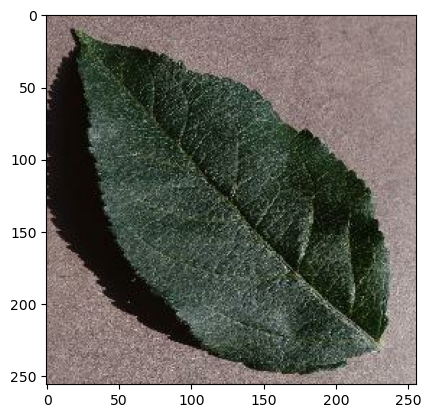

In [31]:
import numpy as np
for images_batch, labels_batch in test_ds.take(1):
    
    first_image = images_batch[0].numpy().astype('uint8')
    first_label = labels_batch[0].numpy()
    
    print("first image to predict")
    plt.imshow(first_image)
    print("actual label:",classes[first_label])
    
    batch_prediction = model.predict(images_batch)
    print("predicted label:",classes[np.argmax(batch_prediction[0])])